This notebook visualizes the resutls of the optuna hyperparameter tuning.

need to train models in order to train this one


In [6]:
import json
import subprocess
import warnings

import matplotlib.pyplot as plt
import numpy as np
import optuna
import optuna.visualization.matplotlib as vis
import pandas as pd

pd.set_option("display.float_format", lambda f: "{:.2e}".format(f) if f < 0.1 else "{}".format(f))

warnings.filterwarnings("ignore")

plt.rcParams.update(
    {
        "text.usetex": True,
        "font.family": "serif",
        "font.size": 8,
        "axes.linewidth": 0.6,
        "xtick.major.width": 0.4,
        "ytick.major.width": 0.4,
        "xtick.major.size": 2,
        "ytick.major.size": 2,
        "axes.labelsize": 8,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "figure.titlesize": 8,
    }
)

In [2]:
def load_dataframe(storage_path, study_name="ae_search"):
    study = optuna.load_study(study_name=study_name, storage=storage_path)
    df = study.trials_dataframe(
        attrs=("number", "value", "params", "state", "datetime_start", "datetime_complete")
    )
    df = df[df["state"] == "COMPLETE"]  # filter out failed/pruned
    df.sort_values("value", inplace=True)  # sort by value
    return df.drop(columns=["state", "datetime_start", "datetime_complete"])


# Connect to local Optuna SQLite DB
def all_plots(storage_path, study_name="ae_search"):
    study = optuna.load_study(study_name=study_name, storage=storage_path)

    # --- Summary Statistics ---
    print(
        f"Number of completed trials: {len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])}"
    )
    print(f"Best value: {study.best_value}")
    print(f"Best parameters:\n{study.best_params}")
    print(f"Best trial number: {study.best_trial.number}")

    # --- Convert all trials to a DataFrame ---
    df = study.trials_dataframe(
        attrs=("number", "value", "params", "state", "datetime_start", "datetime_complete")
    )
    df = df[df["state"] == "COMPLETE"]  # filter out failed/pruned
    display(df.sort_values("value").head(10))  # top 10 results

    # --- Visualizations ---
    vis.plot_slice(study)
    plt.yscale("log")
    plt.ylim(top=1e-2) # Adjust y-axis limit for better visibility

    vis.plot_param_importances(study)

    optuna.visualization.matplotlib.plot_contour(
        study,
        target=lambda trial: np.log10(trial.value),
        target_name="log10(value)",
        params=["hidden_depth", "min_dim", "scaling_factor"],
    )

    optuna.visualization.matplotlib.plot_contour(
        study,
        target=lambda trial: np.log10(trial.value),
        target_name="log10(value)",
        params=["batch_size", "learning_rate"],
    )


# One database

In [3]:
df = load_dataframe("sqlite:///../models/optuna-2/two_rdms/L7-N8-U4.0/ae_search.db")

df.query("params_hidden_depth > 0").sort_values("value").head(10)

,number,value,params_batch_size,params_hidden_depth,params_interpolation,params_learning_rate,params_min_dim,params_scaling_factor
23,23,3.65e-05,32,4,geometric,1.15e-05,79,4.0
3,3,4.15e-05,128,5,geometric,3.39e-05,85,4.0
19,19,4.71e-05,32,4,geometric,1.16e-05,50,3.0
12,12,5.56e-05,32,5,geometric,1.40e-05,88,4.0
17,17,5.79e-05,128,5,geometric,3.78e-05,52,4.0
22,22,6.01e-05,128,3,geometric,1.39e-04,73,1.0
5,5,6.22e-05,128,4,geometric,8.81e-05,41,4.0
13,13,8.84e-05,32,5,geometric,2.73e-05,98,4.0
1,1,9.04e-05,64,5,geometric,4.35e-04,37,2.0
16,16,1.05e-04,64,3,geometric,9.73e-05,76,3.0


Text(0, 0.5, 'Loss Value')

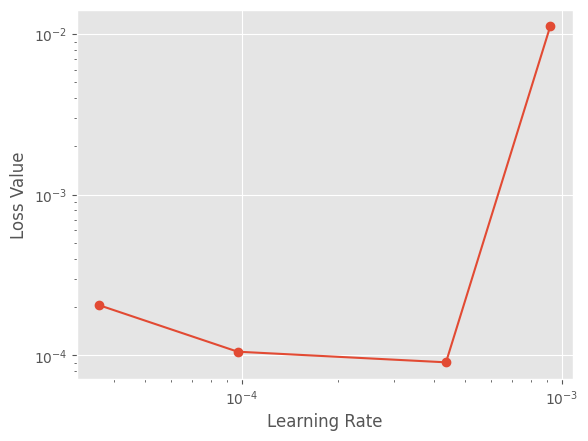

In [13]:
for bs in [64]:
    learning_rates, values = df.query(f"params_batch_size == {bs}").sort_values("params_learning_rate")[
        ["params_learning_rate", "value"]
    ].values.T
    plt.plot(learning_rates, values, marker="o")
plt.yscale("log")
plt.xscale("log")
plt.xlabel("Learning Rate")
plt.ylabel("Loss Value")

Text(0, 0.5, 'Loss Value')

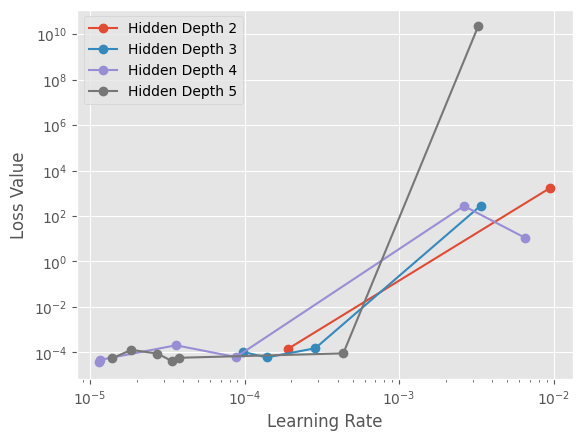

In [14]:
for hd in [2, 3, 4, 5]:
    learning_rates, values = df.query(f"params_hidden_depth == {hd}").sort_values("params_learning_rate")[
        ["params_learning_rate", "value"]
    ].values.T
    plt.plot(learning_rates, values, marker="o", label=f"Hidden Depth {hd}")
plt.legend()
plt.yscale("log")
plt.xscale("log")
plt.xlabel("Learning Rate")
plt.ylabel("Loss Value")

# Summary of all best trials

In [20]:
ln_list = [(4, 4), (5, 4), (5, 6), (6, 6), (7, 6), (7, 8), (8, 8)]

trials_per_dataset = 6

dir_list = [f"ham_terms/L{L}-N{N}-U4.0" for L, N in ln_list] + [
    f"two_rdms/L{L}-N{N}-U4.0" for L, N in ln_list
]
study_name = "ae_search"


all_results = []

for dir_name in dir_list:
    storage_path = f"sqlite:///../models/optuna-2/{dir_name}/ae_search.db"
    base_path = f"../models/optuna-2/{dir_name}"
    study = optuna.load_study(study_name=study_name, storage=storage_path)

    trials = sorted(study.trials, key=lambda t: t.value or float("inf"))
    tot_n_trials = len(trials)
    top_trials = trials[:trials_per_dataset]
    for trial in top_trials:
        all_results.append({"data_type": dir_name.split("/")[0], "system": dir_name.split("/")[1], **trial.params, "value": trial.value, "tot_n_trials": tot_n_trials, "trial_number": trial.number})

    if False:  # Set to True to save the best parameters in a JSON file
        with open(f"{base_path}/best_params.json", "w") as f:
            json.dump(study.best_params, f, indent=2)

    if False:  # Set to True to download the best trial model
        try:
            study.best_trial.number 
        except ValueError:
            print(f"No completed trials found for {dir_name}. Skipping download.")
            continue
        if tot_n_trials < 10:
            print(f"Not enough trials for {dir_name}. Skipping download.")
            continue
        source_path = f"alice:/home/pollas1/data_pi-pollas1/dftqml-compression-models/optuna-2/"
        include_path = f"{dir_name}/trial_{study.best_trial.number}/***"
        print(include_path)

        cmd = f"rsync -avz  --include='{dir_name.split('/')[0]}' --include='{dir_name}' --include='{include_path}' --exclude='*' {source_path} models/optuna-2/"
        print(cmd)
        subprocess.run(cmd, shell=True)

best_params_df = pd.DataFrame(all_results)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
# best_params_df
best_params_df["L"] = best_params_df["system"].str.extract(r"L(\d+)").astype(int)

In [25]:
param_cols = [
    c for c in best_params_df.columns
    if c not in {"data_type", "system", "value", "tot_n_trials", "trial_number", "L", "interpolation"}
]

numeric_params = [
    c for c in param_cols
    if pd.api.types.is_numeric_dtype(best_params_df[c])
]

print("Numeric:", numeric_params)

agg = (
    best_params_df
    .groupby(["data_type", "L"])[numeric_params]
    .agg(["median", "std"])
    .reset_index()
)

Numeric: ['hidden_depth', 'min_dim', 'learning_rate', 'batch_size', 'scaling_factor']


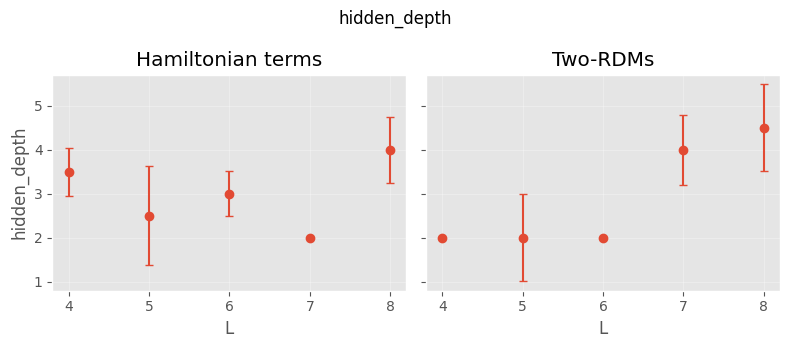

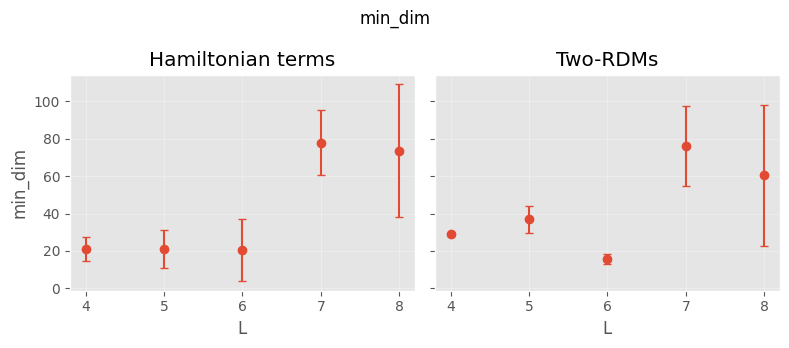

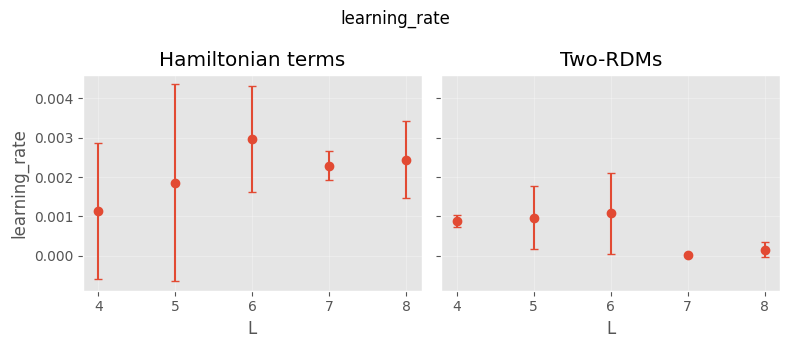

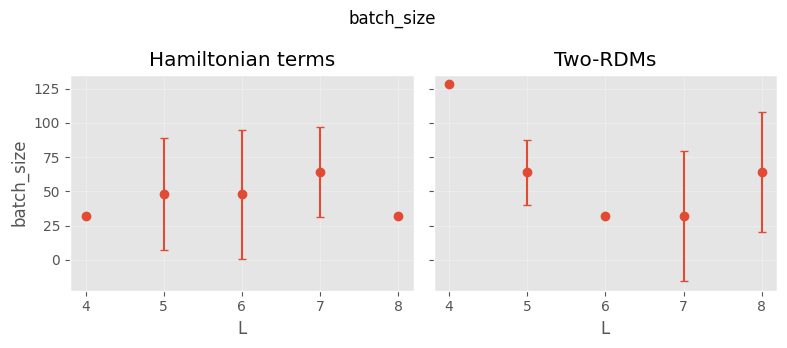

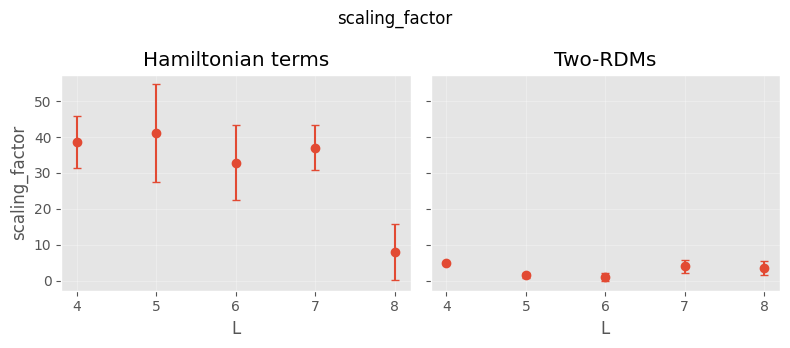

In [26]:
import matplotlib.pyplot as plt

for param in param_cols:
    fig, axes = plt.subplots(
        1, 2, figsize=(8, 3.5), sharey=True, sharex=True
    )

    for ax, data_type, title in zip(
        axes,
        ["ham_terms", "two_rdms"],
        ["Hamiltonian terms", "Two-RDMs"],
    ):
        sub = agg[agg["data_type"] == data_type]

        ax.errorbar(
            sub["L"],
            sub[(param, "median")],
            yerr=sub[(param, "std")],
            fmt="o",
            capsize=3,
        )

        ax.set_title(title)
        ax.set_xlabel("L")
        ax.grid(alpha=0.3)

    axes[0].set_ylabel(f"{param}")

    fig.suptitle(param)
    fig.tight_layout()
    plt.show()
